In [ ]:
from IPython.core.display import HTML
from IPython.core.pylabtools import figsize
import matplotlib as mpl

figsize(17, 3.2)
mpl.rcParams['agg.path.chunksize'] = 10000

In [ ]:
import numpy as np
import scipy.special as sp
from  scipy.constants import c
import matplotlib.pyplot as plt
#!pip install OptiCommPy
#from optic.utils import parameters
#from optic.dsp.core import firFilter, signal_power, pulseShape, upsample, pnorm
#from optic.models.devices import mzm, photodiode
#from optic.plot import eyediagram

## Propagação_de_Pulsos_ópticos_SSFM.
---

## Sumário
---
- [Introdução](#introdução)
- [-](#-)
- [-](#-")
- [-](#-)

### Introdução

Nas fibras ópticas reais, quando a intensidade do sinal óptico (potência) é elevada, como acontece em longas distâncias ou altas taxas de transmissão, os efeitos não lineares do material da fibra passam a se manifestar de forma significativa. Esses efeitos distorcem a forma do pulso durante sua propagação, provocando alargamento temporal, mudança de frequência (chirp) e interferência entre símbolos.

A equação que descreve a propagação de um pulso óptico em uma fibra óptica com coeficiente de perdas igual a $α$, coeficiente GVD $β_2$ e coeficiente não linear $γ$ é igual a:

$$\begin{equation}
j\frac{\partial A}{\partial z} + j\frac{\alpha}{2}A -
\frac{\beta_2}{2}\frac{\partial^2 A}{\partial t^2} +
γ|A|^2A = 0
\end{equation}$$

em que $A(z,t)$ é a amplitude do sinal na posição $z$ e tempo $t$. $A_{eff}$ a área efetiva do modo na fibra que varia entre 20-100 $μm^2$ na região 1550nm. Importante lembrar que o parâmetro de dispersão [ps/(km.nm)] é definido como:

$$D = \frac{2\pi c}{λ^2}\beta_2 ⟶
\gamma = \frac{n_2\omega_0}{cA_{eff}} ⟶
A_{eff} = \pi \omega^2
$$


In [ ]:
def SSF_non_symmetric(E, hz, Lspan, alpha, gamma, D, Fc, Fs):
    λ  = c/Fc
    α  = 1e-3*alpha/(10*np.log10(np.exp(1)))
    β2 = -(D*λ**2)/(2*np.pi*c)

    Nfft = len(E)
    ω = 2*np.pi*Fs*np.fft.fftfreq(Nfft)

    z = 0
    while z <= Lspan:
        # Operador linear
        E = np.fft.fft(E)
        E = E*np.exp(-α*hz+1j*(β2/2)*(ω**2)*hz)

        # Operador não linear
        E = np.fft.ifft(E)
        E = E*np.exp(1j*gamma*(np.abs(E)**2)*hz)

        z += hz
    return E,z

In [ ]:
Lspan = 10e3  # m
hz    = 0.1e2  # m
alpha = 0.2    # dB/km
gamma = 1.3e-3 # W-1/m
D  = 0#16e-6     # s/(m*m)
Fc = 193.1e12  # Hz
Fs = 64e9      # Hz
P0 = 1e-3      # W

def GaussPulse(a0, t0, t):      # Expressão do pulso Gaussiano
  return a0*np.exp(-0.5*(t/t0)**2)
def FGaussPulse(a0, t0, freq):  # Transformada de Fourier do pulso Gaussiano (analítica)
  return a0*t0*np.sqrt(2*np.pi)*np.exp(-0.5*(2*np.pi*freq*t0)**2)


t0 = 0.1
fs = 80                         # Taxa de amostragem
t  = np.arange(-0.5,0.5,1/fs)   # Duração da janela do pulso
E  = GaussPulse(np.sqrt(P0), t0, t)


E_out, z  = SSF_non_symmetric(E, hz, Lspan, alpha, gamma, D, Fc, Fs)
alpha_lin = 1e-3*alpha/(10*np.log10(np.exp(1)))
E_rx = E_out*np.exp(alpha_lin * z)
delta_w = -np.diff(np.angle(E_rx))/(t[1]-t[0])

z = 10.010000 km


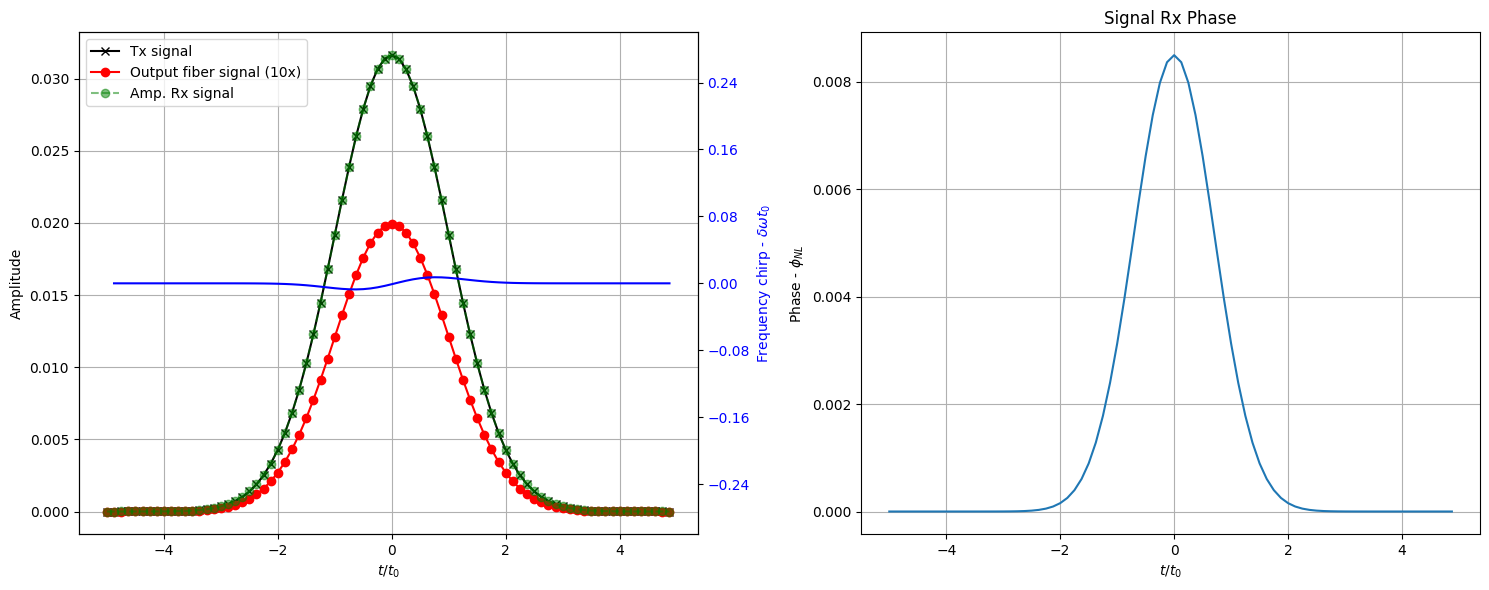

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15,6))
axs[0].plot(t/t0, np.abs(E),     'kx-',  label = 'Tx signal')
axs[0].plot(t/t0, np.abs(E_out), 'ro-',  label = 'Output fiber signal (10x)')
axs[0].plot(t/t0, np.abs(E_rx),  'go--', label = 'Amp. Rx signal', alpha = 0.5)
axs[0].set_xlabel(r'$t/t_0$')
axs[0].set_ylabel('Amplitude')
#axs[0].set_ylim([0,0.2])
axs[0].legend(loc = 'upper left')
axs[0].grid(True)

axs1 = axs[0].twinx()
axs1.plot(t[1:]/t0, t0*delta_w, 'blue')
axs1.set_ylabel('Frequency chirp - $\delta \omega t_0$', color = 'blue')
axs1.tick_params(axis='y', labelcolor='blue')
axs1.set_ylim([-.3,.3])
axs1.yaxis.set_major_locator(plt.MaxNLocator(9))

axs[1].plot(t/t0, np.angle(E_rx))
axs[1].set_xlabel(r'$t/t_0$')
axs[1].set_ylabel('Phase - $\phi_{NL}$')
axs[1].set_title('Signal Rx Phase')
axs[1].grid(True)
print('z = %f km' %(1e-3*z))

fig.tight_layout()